# Data Augmentation 적용 RPS

## 모듈 로딩

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.model_selection import train_test_split

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))

NumPy Version :2.0.2
TensorFlow Version :2.19.0
Matplotlib Version :3.10.0


## g-drive 마운트

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('g-drive mounted.')
    colab=True
except:
    print('local drive.')
    colab =False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
g-drive mounted.


## RPS 데이터셋 준비

In [ ]:
# files_path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  !unzip -q -o /content/drive/MyDrive/files/RPS_Dataset.zip
  files_path = '/content/RPS_Dataset'
else :
  files_path = '../files/RPS_Dataset'

## 폴더 별로 파일 읽어 데이터화 진행

In [ ]:
IMG_SIZE = 224

In [ ]:
%%time
first = True
for ind in range(0, 3, 1) :
    path = files_path + '/' + str(ind) + '/*.*'
    print(path)
    files = glob.glob(path)
    tmpx = np.array([(cv2.resize(cv2.cvtColor(cv2.imread(x, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB), (IMG_SIZE,IMG_SIZE))) for x in files])
    tmpy = np.array([ind] * len(files))

    xtrain, xtest, ytrain, ytest = train_test_split(tmpx, tmpy, test_size=0.2, random_state=123)

    if first == True:
        train_data = xtrain.copy()
        train_labels = ytrain.copy()
        test_data = xtest.copy()
        test_labels = ytest.copy()
        first = False
    else :
        train_data = np.concatenate((train_data, xtrain))
        train_labels = np.concatenate((train_labels, ytrain))
        test_data = np.concatenate((test_data, xtest))
        test_labels = np.concatenate((test_labels, ytest))

/content/RPS_Dataset/0/*.*
/content/RPS_Dataset/1/*.*
/content/RPS_Dataset/2/*.*
CPU times: user 7.13 s, sys: 524 ms, total: 7.65 s
Wall time: 7.66 s


## 데이터 확인

In [ ]:
# Normalization 처리 안함 (모델 내에서 -1 ~ 1로 변환 처리함)
# train_data = train_data / 255.0
# test_data = test_data / 255.0

print(train_data.shape)
print(train_labels.shape)
print(test_data.shape)
print(test_labels.shape)

(2172, 224, 224, 3)
(2172,)
(545, 224, 224, 3)
(545,)


## ImageDataGenerator 객체 생성

In [ ]:
img_gen_train = tf.keras.preprocessing.image.ImageDataGenerator(
                horizontal_flip=True,        # 좌우 반전 여부 설정
                rotation_range=0.2,          # 회전 범위 설정
                width_shift_range=0.1,       # 좌우로 이동할 범위 설정
                height_shift_range=0.1,      # 상하로 이동할 범위 설정
                brightness_range=(0.1, 0.9), # 밝기 범위 설정
                zoom_range=0.2               # 줌 범위 설정
                )                            # 이외에도 다양한 설정 가능

train_gen = img_gen_train.flow(train_data, train_labels, seed = 1)

## 모델 생성


In [ ]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_tensor = x
)
base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(3, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

/tmp/ipython-input-734412442.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_1          │ (None, 224, 224,  │          0 │ true_divide_1[0]… │
│ (Subtract)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ subtract_1[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 모델 컴파일

In [ ]:
model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## 학습 전 상황

In [ ]:
def Make_Result_Plot(suptitle, data, label, y_max):
    size = data.shape[0]//10
    fig_result, ax_result = plt.subplots(2,5,figsize=(18, 7))
    fig_result.suptitle(suptitle)
    for idx in range(10):
        cnt = idx * size + size//2
        ax_result[idx//5,idx%5].imshow(data[cnt].reshape((IMG_SIZE,IMG_SIZE, 3)))
        ax_result[idx//5,idx%5].set_title("test_data[{}] (label : {} / y : {})".format(cnt, label[cnt], y_max[cnt]))

18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 263ms/step


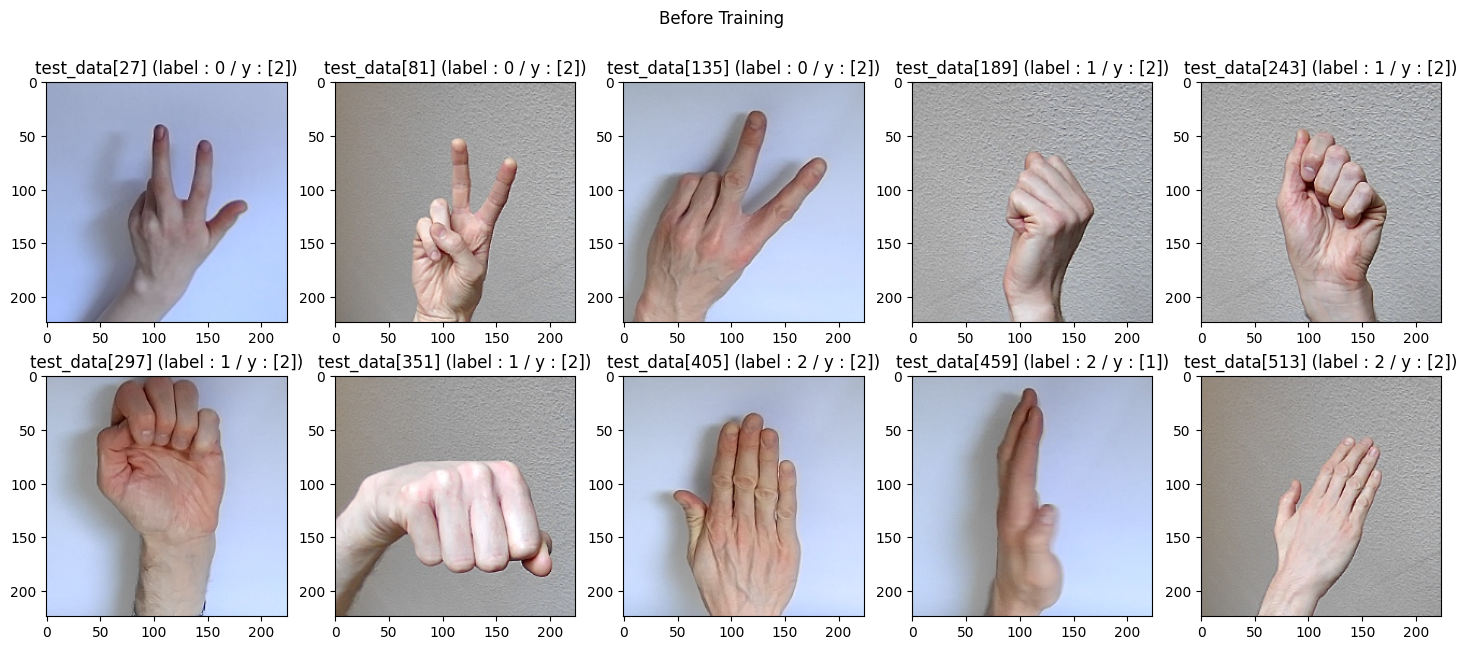

In [ ]:
y_out = model.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("Before Training", test_data, test_labels, y_max)

## 콜백 설정

In [ ]:
savedModelName = 'RPS_MobileNetV2_Augmentation.keras'
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(savedModelName,
                                    save_best_only=True)
]

## 모델 학습

In [ ]:
%%time
history = model.fit(train_gen, epochs=30,
                    callbacks=callbacks,
                    validation_data=(test_data, test_labels))

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 49s 578ms/step - accuracy: 0.5440 - loss: 0.9856 - val_accuracy: 0.8440 - val_loss: 0.4903
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 407ms/step - accuracy: 0.8330 - loss: 0.4824 - val_accuracy: 0.9064 - val_loss: 0.3348
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 406ms/step - accuracy: 0.8755 - loss: 0.3512 - val_accuracy: 0.9339 - val_loss: 0.2566
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 410ms/step - accuracy: 0.9178 - loss: 0.2448 - val_accuracy: 0.9505 - val_loss: 0.2076
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 411ms/step - accuracy: 0.9423 - loss: 0.2094 - val_accuracy: 0.9578 - val_loss: 0.1815
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 408ms/step - accuracy: 0.9430 - loss: 0.1842 - val_accuracy: 0.9578 - val_loss: 0.1653
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 409ms/step - accuracy: 0.9447 - loss: 0.1675 - val_accuracy: 0.9706 - val_loss: 0.1371
Epoch 8/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 401ms/step - accuracy: 0.9601 - loss: 0.1423 - val_accu

## Ploting : Cost/Training Count

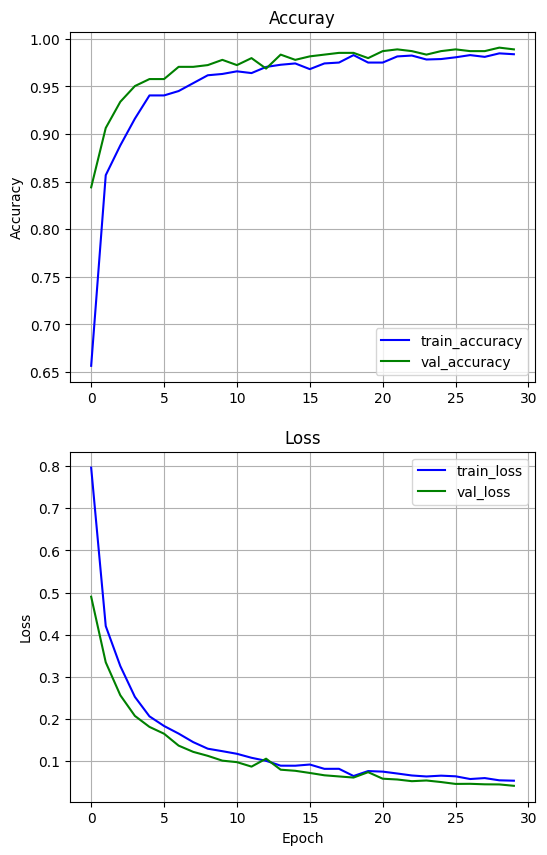

In [ ]:
plt.figure(figsize=(6, 10))
plt.subplot(2, 1, 1)
plt.title('Accuray')
plt.plot(history.history['accuracy'], 'b', label='train_accuracy')
plt.plot(history.history['val_accuracy'], 'g', label='val_accuracy')
# plt.ylim([0,1])
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(history.history['loss'], 'b', label='train_loss')
plt.plot(history.history['val_loss'], 'g', label='val_loss')
# plt.ylim([0,5])
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

## best 모델 로딩 및 테스트

In [ ]:
model_best = tf.keras.models.load_model (savedModelName)

18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 319ms/step


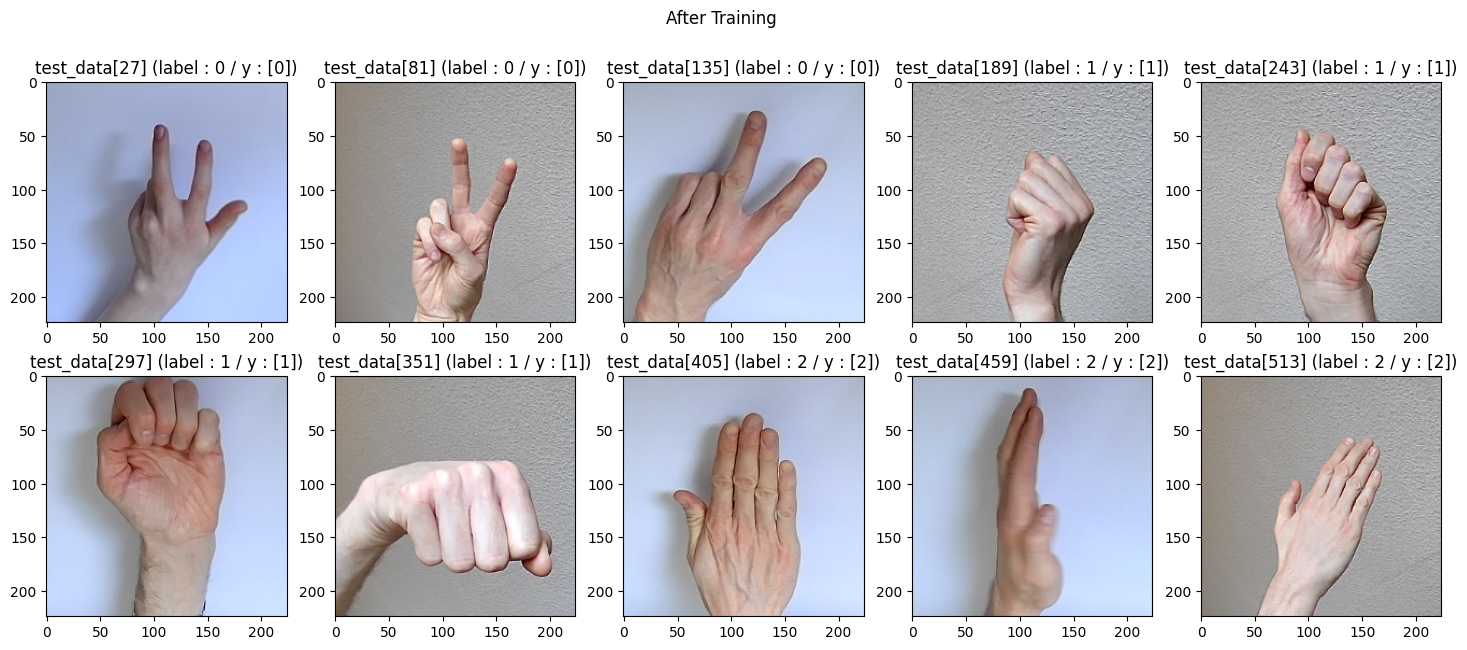

In [ ]:
y_out = model_best.predict(test_data)
y_max = np.argmax(y_out, axis=1).reshape((-1, 1))
Make_Result_Plot("After Training", test_data, test_labels, y_max)

## best 모델 백업

In [ ]:
# save_dir: 다른 경로에 저장하려면, 아래 경로를 수정하세요
if colab :
  save_dir = '/content/drive/MyDrive/files/save/'
else :
  save_dir = '../files/save/'

In [ ]:
# copy saved mode
cpCmd = f'cp {savedModelName} {save_dir}'
print(cpCmd)
!{cpCmd}

cp RPS_MobileNetV2_Augmentation.keras /content/drive/MyDrive/files/save/


## LiteRT 모델로 변환

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_best)
tflite_model = converter.convert()

Saved artifact at '/tmp/tmppj1mvwmn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140029611876688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140029617288400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140029617286288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140029611875152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140029617287824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140029617286480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140029617284368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140028826054544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140029617288592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140029617289744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1400288260430

## LiteRT 모델을 파일로 저장

In [ ]:
tfliteFileName = 'RPS_MobileNetV2_Augmentation.tflite'

In [ ]:
open(save_dir + tfliteFileName, 'wb').write(tflite_model)

9517460